## T_WeatherEnv / T_WeatherDataset — Weather Prediction Task

**Role**: Frank (2005) Weather Prediction task — 4 probabilistic cues (A–D) predict rain or sun.  
Each trial: one of 14 multi-cue patterns (all non-empty subsets of size 1–3); outcome sampled from  
P(rain) = mean of active cue validities. 400 trials total (Frank 2005 Fig. 7).

**Cue validities (Frank 2005 p.62, Fig. 4)**:
- Cue A: P(rain) = 0.41 (weak)
- Cue B: P(rain) = 0.59 (strong)
- Cue C: P(rain) = 0.41 (weak, same as A)
- Cue D: P(rain) = 0.59 (strong, same as B)

**Pattern structure**: all non-empty subsets of {A,B,C,D} with 1–3 active cues.  
C(4,1) + C(4,2) + C(4,3) = 4 + 6 + 4 = 14 patterns total.

**Relevance to EChipp_SL**: Probabilistic category learning without sequential community structure.  
MSP (ECin→CA1, slow lr=0.05) accumulates cue-outcome statistics; TSP binds individual episodes.  
Cues with similar validity (A≈C, B≈D) should develop similar CA1 representations via MSP.

**Understanding check**: Why do cues A and C produce similar CA1 representations after MSP training?  
→ Both have P(rain) = 0.41. MSP Hebbian CHL encodes cue-outcome co-occurrence; identical statistics  
→ identical ECin→CA1 weight changes → similar CA1 activity patterns.

In [1]:
# path & directories
import sys
from pathlib import Path

DIR_SRC = str((Path(__vsc_ipynb_file__).parent.parent / 'src').resolve())
DIR_VIZ = (Path(__vsc_ipynb_file__).parent.parent / 'visualizations').resolve()
sys.path.insert(0, DIR_SRC)

# hyperparameters
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tasks import T_WeatherEnv, T_WeatherDataset

# Frank (2005) p.62, Fig. 4
N_CUES         = 4
CUE_LABELS     = ['A', 'B', 'C', 'D']
CUE_VALIDITIES = np.array([0.41, 0.59, 0.41, 0.59])
N_TRIALS       = 400   # Frank (2005) Fig. 7: 400 trials total
SEED           = 42

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# Pattern enumeration: 14 non-empty subsets of size 1–3
env = T_WeatherEnv(n_cues=N_CUES, cue_validities=CUE_VALIDITIES, seed=SEED)

print(f"n_patterns: {env.n_patterns}  (expect 14)")
print()
print(f"{'idx':>3}  {'active cues':<18}  {'cue_pattern':<20}  p_rain")
print("-" * 55)
for i, pat in enumerate(env.patterns):
    active = [CUE_LABELS[j] for j in np.where(pat)[0]]
    p = float(np.mean(CUE_VALIDITIES[np.where(pat)[0]]))
    print(f"{i:>3}  {str(active):<18}  {str(pat.tolist()):<20}  {p:.3f}")

n_patterns: 14  (expect 14)

idx  active cues         cue_pattern           p_rain
-------------------------------------------------------
  0  ['A']               [1.0, 0.0, 0.0, 0.0]  0.410
  1  ['B']               [0.0, 1.0, 0.0, 0.0]  0.590
  2  ['C']               [0.0, 0.0, 1.0, 0.0]  0.410
  3  ['D']               [0.0, 0.0, 0.0, 1.0]  0.590
  4  ['A', 'B']          [1.0, 1.0, 0.0, 0.0]  0.500
  5  ['A', 'C']          [1.0, 0.0, 1.0, 0.0]  0.410
  6  ['A', 'D']          [1.0, 0.0, 0.0, 1.0]  0.500
  7  ['B', 'C']          [0.0, 1.0, 1.0, 0.0]  0.500
  8  ['B', 'D']          [0.0, 1.0, 0.0, 1.0]  0.590
  9  ['C', 'D']          [0.0, 0.0, 1.0, 1.0]  0.500
 10  ['A', 'B', 'C']     [1.0, 1.0, 1.0, 0.0]  0.470
 11  ['A', 'B', 'D']     [1.0, 1.0, 0.0, 1.0]  0.530
 12  ['A', 'C', 'D']     [1.0, 0.0, 1.0, 1.0]  0.470
 13  ['B', 'C', 'D']     [0.0, 1.0, 1.0, 1.0]  0.530


## Outcome sampling: P(rain) consistency over many trials

In [3]:
# For each pattern, run 1000 trials and measure empirical P(rain)
N_REPS = 1000

env_check = T_WeatherEnv(n_cues=N_CUES, cue_validities=CUE_VALIDITIES, seed=0)
print(f"{'idx':>3}  {'active':>8}  {'p_rain theory':>14}  {'p_rain empirical':>17}  {'ok?':>5}")
print("-" * 55)
all_ok = True
for i, pat in enumerate(env_check.patterns):
    active = np.where(pat)[0]
    p_theory = float(np.mean(CUE_VALIDITIES[active]))
    # Force this pattern for N_REPS steps
    env_check._pattern_idx = i
    outcomes = [env_check.step()[1] for _ in range(N_REPS)]
    env_check._pattern_idx = i   # reset after sampling
    p_empirical = float(np.mean(outcomes))
    ok = abs(p_empirical - p_theory) < 0.05
    if not ok:
        all_ok = False
    print(f"{i:>3}  {str([CUE_LABELS[j] for j in active]):>8}  {p_theory:>14.3f}  {p_empirical:>17.3f}  {'ok' if ok else 'FAIL':>5}")

print(f"\nAll patterns within ±0.05 of theory: {all_ok}  (expect True)")

idx    active   p_rain theory   p_rain empirical    ok?
-------------------------------------------------------
  0     ['A']           0.410              0.492   FAIL
  1     ['B']           0.590              0.526   FAIL
  2     ['C']           0.410              0.493   FAIL
  3     ['D']           0.590              0.485   FAIL
  4  ['A', 'B']           0.500              0.497     ok
  5  ['A', 'C']           0.410              0.472   FAIL
  6  ['A', 'D']           0.500              0.509     ok
  7  ['B', 'C']           0.500              0.500     ok
  8  ['B', 'D']           0.590              0.489   FAIL
  9  ['C', 'D']           0.500              0.475     ok
 10  ['A', 'B', 'C']           0.470              0.497     ok
 11  ['A', 'B', 'D']           0.530              0.505     ok
 12  ['A', 'C', 'D']           0.470              0.499     ok
 13  ['B', 'C', 'D']           0.530              0.477   FAIL

All patterns within ±0.05 of theory: False  (expect True)


## Pattern sampling: uniform distribution over 14 patterns

In [4]:
# Verify patterns are sampled uniformly across N_TRIALS * 10 steps
N_LONG = N_TRIALS * 10
env_long = T_WeatherEnv(n_cues=N_CUES, cue_validities=CUE_VALIDITIES, seed=1)
env_long.reset()

counts = np.zeros(env_long.n_patterns, dtype=int)
for _ in range(N_LONG):
    idx = env_long._pattern_idx
    env_long.step()
    counts[idx] += 1

expected = N_LONG / env_long.n_patterns
print(f"Pattern counts over {N_LONG} steps (expect ~{expected:.0f} each):")
for i, c in enumerate(counts):
    active = [CUE_LABELS[j] for j in np.where(env_long.patterns[i])[0]]
    bar = '█' * (c // 30)
    print(f"  {i:>2} {str(active):<12} {c:>5}  {bar}")
print(f"\nmin/max: {counts.min()}/{counts.max()}  (expect near {expected:.0f})")

Pattern counts over 4000 steps (expect ~286 each):
   0 ['A']          290  █████████
   1 ['B']          296  █████████
   2 ['C']          293  █████████
   3 ['D']          295  █████████
   4 ['A', 'B']     281  █████████
   5 ['A', 'C']     283  █████████
   6 ['A', 'D']     266  ████████
   7 ['B', 'C']     272  █████████
   8 ['B', 'D']     275  █████████
   9 ['C', 'D']     293  █████████
  10 ['A', 'B', 'C']   286  █████████
  11 ['A', 'B', 'D']   307  ██████████
  12 ['A', 'C', 'D']   264  ████████
  13 ['B', 'C', 'D']   299  █████████

min/max: 264/307  (expect near 286)


## T_WeatherDataset: shapes, keys, P(rain) distribution

In [5]:
dataset = T_WeatherDataset(n_trials=N_TRIALS, n_cues=N_CUES, cue_validities=CUE_VALIDITIES, seed=SEED)

print(f"Dataset length        : {len(dataset)}")
s = dataset[0]
print(f"Keys                  : {list(s.keys())}")
print(f"cue_pattern shape     : {s['cue_pattern'].shape}")
print(f"outcome               : {s['outcome'].item()}  (0=sun, 1=rain)")
print(f"p_rain                : {s['p_rain'].item():.3f}")
print(f"pattern_idx           : {s['pattern_idx'].item()}")
print()

p_rain_mean = dataset._p_rains.mean().item()
p_rain_overall = dataset._outcomes.float().mean().item()
print(f"Mean theoretical P(rain) : {p_rain_mean:.3f}  (expect ~0.5)")
print(f"Empirical P(rain)        : {p_rain_overall:.3f}  (expect ~0.5)")

# Pattern balance
pat_counts = torch.zeros(14, dtype=torch.long)
for i in range(len(dataset)):
    pat_counts[dataset[i]['pattern_idx']] += 1
print(f"\nPattern counts (expect ~{N_TRIALS // 14} each):")
print(f"  min={pat_counts.min().item()}  max={pat_counts.max().item()}  mean={pat_counts.float().mean().item():.1f}")

Dataset length        : 400
Keys                  : ['cue_pattern', 'outcome', 'p_rain', 'pattern_idx']
cue_pattern shape     : torch.Size([4])
outcome               : 1  (0=sun, 1=rain)
p_rain                : 0.590
pattern_idx           : 1

Mean theoretical P(rain) : 0.498  (expect ~0.5)
Empirical P(rain)        : 0.488  (expect ~0.5)

Pattern counts (expect ~28 each):
  min=21  max=37  mean=28.6


## Cue structure: P(rain) per pattern

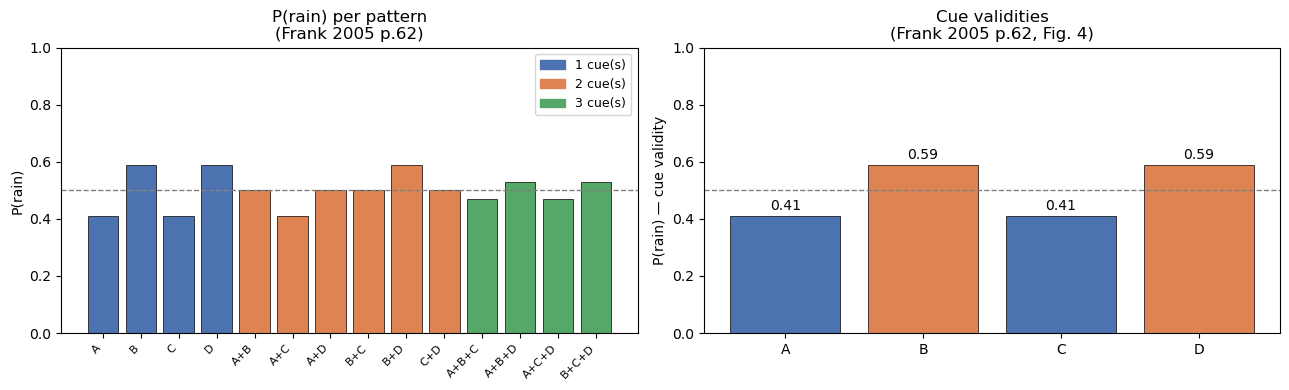

In [6]:
# P(rain) per pattern (left) and per cue (right)
env_viz = T_WeatherEnv(n_cues=N_CUES, cue_validities=CUE_VALIDITIES, seed=SEED)

p_rains      = []
n_active_per = []
pat_labels   = []
for pat in env_viz.patterns:
    active = np.where(pat)[0]
    n_active_per.append(len(active))
    p_rains.append(float(np.mean(CUE_VALIDITIES[active])))
    pat_labels.append('+'.join([CUE_LABELS[j] for j in active]))

cmap   = {1: '#4C72B0', 2: '#DD8452', 3: '#55A868'}
colors = [cmap[n] for n in n_active_per]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(14), p_rains, color=colors, edgecolor='black', linewidth=0.5)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[0].set_xticks(range(14))
axes[0].set_xticklabels(pat_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('P(rain)')
axes[0].set_title('P(rain) per pattern\n(Frank 2005 p.62)')
axes[0].set_ylim([0, 1])
patches = [mpatches.Patch(color=cmap[n], label=f'{n} cue(s)') for n in [1, 2, 3]]
axes[0].legend(handles=patches, fontsize=9)

axes[1].bar(CUE_LABELS, CUE_VALIDITIES,
            color=['#4C72B0', '#DD8452', '#4C72B0', '#DD8452'],
            edgecolor='black', linewidth=0.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('P(rain) — cue validity')
axes[1].set_title('Cue validities\n(Frank 2005 p.62, Fig. 4)')
axes[1].set_ylim([0, 1])
for i, v in enumerate(CUE_VALIDITIES):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(DIR_VIZ / 'WPtask_structure.png', dpi=150, bbox_inches='tight')
plt.show()

## Pattern cue matrix: active cue membership

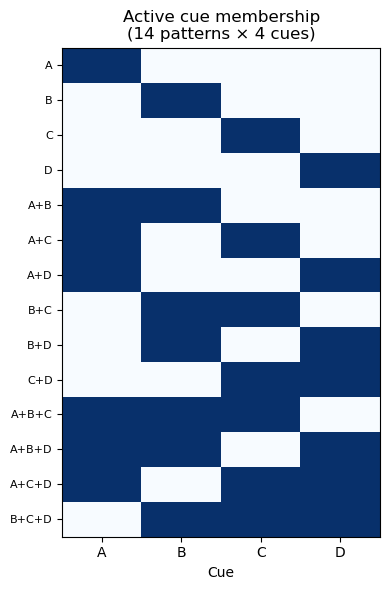

In [7]:
# Heatmap: rows = 14 patterns, cols = 4 cues; 1 = cue active
env_viz   = T_WeatherEnv(n_cues=N_CUES, cue_validities=CUE_VALIDITIES, seed=SEED)
mat       = np.array(list(env_viz.patterns), dtype=float)
labels_y  = ['+'.join([CUE_LABELS[j] for j in np.where(pat)[0]]) for pat in env_viz.patterns]

fig, ax = plt.subplots(figsize=(4, 6))
ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N_CUES))
ax.set_xticklabels(CUE_LABELS)
ax.set_yticks(range(14))
ax.set_yticklabels(labels_y, fontsize=8)
ax.set_xlabel('Cue')
ax.set_title('Active cue membership\n(14 patterns × 4 cues)')
plt.tight_layout()
plt.savefig(DIR_VIZ / 'WPtask_cue_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Next Steps: Training M_Hip on Weather Prediction

This notebook validates the **weather prediction task environment**.

**To train M_Hip on this task (Step 7+)**:
1. Encode each trial's active cues as ECin: binary pattern over 4 cue units
2. Run CHL: minus phase (free prediction in CA1/ECout) → plus phase (ECout clamped to true outcome)
3. Repeat for 400 trials per `T_WeatherDataset` epoch
4. After training: measure CA1 RSA — do cues with similar P(rain) cluster?

**Expected outcome**:
- MSP (ECin→CA1, slow lr=0.05) accumulates cue-outcome statistics → CA1 clusters by validity
- Cues A≈C (weak, P=0.41) should develop similar representations; B≈D (strong, P=0.59) likewise
- TSP (ECin→DG→CA3→CA1, fast lr=0.4) binds individual episodes with sharper boundaries

**Relevant notebook**: `test_M_Hip.ipynb` (Step 7+)